# Dataset Creation

## Objective

The preprocessed LIGO strain signal is converted into fixed-length windows that will serve as individual samples for machine learning.

Each window represents a short segment of the detector output and will later be classified by the neural network.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import numpy as np

processed_signal = np.load("../data/processed/h1_processed.npy")

print(processed_signal.shape)

(131072,)


In [4]:
fs = 4096

In [5]:
window_duration = 1  # seconds

window_size = fs * window_duration

print("Window Size:", window_size)

Window Size: 4096


In [6]:
def create_windows(signal, window_size):
    windows = []

    for start in range(0, len(signal), window_size):
        end = start + window_size

        if end <= len(signal):
            windows.append(signal[start:end])

    return np.array(windows)

In [7]:
windows = create_windows(processed_signal, window_size)

print("Dataset Shape:", windows.shape)

Dataset Shape: (32, 4096)


In [8]:
print(windows[0].shape)
print(windows[0][:10])

(4096,)
[0.32104002 3.4731661  6.16346222 8.07941532 9.13344585 9.44209852
 9.24150736 8.79160535 8.3036999  7.90308722]


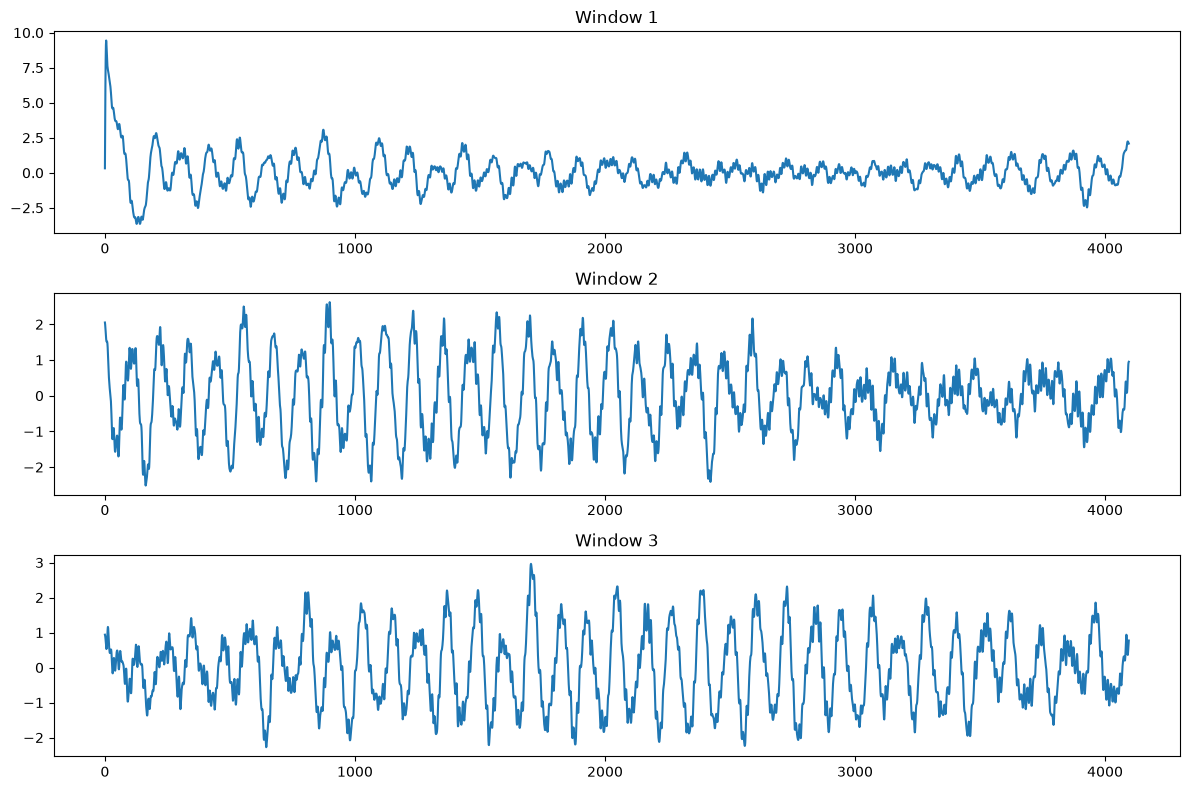

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i in range(3):
    axes[i].plot(windows[i])
    axes[i].set_title(f"Window {i+1}")

plt.tight_layout()
plt.show()

In [10]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/windows.npy", windows)

print("Window dataset saved successfully!")

Window dataset saved successfully!


In [11]:
loaded_windows = np.load("../data/processed/windows.npy")

print("Loaded shape:", loaded_windows.shape)

Loaded shape: (32, 4096)


## Dataset Creation Summary

The preprocessed LIGO strain signal was divided into fixed-length windows for machine learning.

### Configuration

- Sampling frequency: **4096 Hz**
- Window duration: **1 second**
- Samples per window: **4096**
- Total windows generated: **32**

Each window represents an individual training sample that can later be used for feature extraction and neural network training.